# TD 3 — Transformation, exploration et inférence (chapitres 5–7)

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
sys.path.insert(0, str(DATA.parents[1] / "src"))
from atd import nettoyer_ventes   # fonction de nettoyage du chapitre 4

ventes, _ = nettoyer_ventes(pd.read_csv(DATA / "ventes_boutiques.csv"), pd.read_csv(DATA / "regions_senegal.csv")["region"])
etu = pd.read_csv(DATA / "resultats_etudiants.csv")
sns.set_theme(style="whitegrid", palette="colorblind")

## Exercice 1 ⭐ — groupby / agg
Pour chaque **catégorie** de produit : nombre de transactions, CA total, panier médian, et part du CA total (%).
Triez par CA décroissant.

In [2]:
t = ventes.groupby("categorie", observed=True).agg(n=("id_transaction", "count"), ca=("montant", "sum"),
                                                   panier_median=("montant", "median"))
t["part_ca_%"] = (100 * t["ca"] / t["ca"].sum()).round(1)
t.sort_values("ca", ascending=False)

,n,ca,panier_median,part_ca_%
categorie,,,,
Alimentaire,2426,28098190.0,4600.0,69.5
Services,839,7695290.0,5150.0,19.0
Fournitures,856,2536190.0,2220.0,6.3
Hygiène,879,2073380.0,2020.0,5.1


## Exercice 2 ⭐⭐ — transform
Ajoutez à `ventes` une colonne `prix_relatif` = prix unitaire / prix **médian du même produit**.
Quelle région pratique en moyenne les prix relatifs les plus élevés ?

In [3]:
ventes["prix_relatif"] = ventes["prix_unitaire"] / ventes.groupby("produit")["prix_unitaire"].transform("median")
ventes.groupby("region", observed=True)["prix_relatif"].mean().sort_values(ascending=False).round(4)

region
Tambacounda    1.0049
Kaolack        1.0026
Ziguinchor     1.0019
Thiès          1.0015
Dakar          0.9996
Diourbel       0.9989
Saint-Louis    0.9981
Louga          0.9974
Name: prix_relatif, dtype: float64

## Exercice 3 ⭐⭐ — pivot et melt
1. Construisez un tableau **large** : lignes = région, colonnes = trimestre (1–4), valeurs = CA.
2. Repassez-le au format **long** puis tracez un graphique en barres groupées (seaborn `barplot`, `hue="trimestre"`).

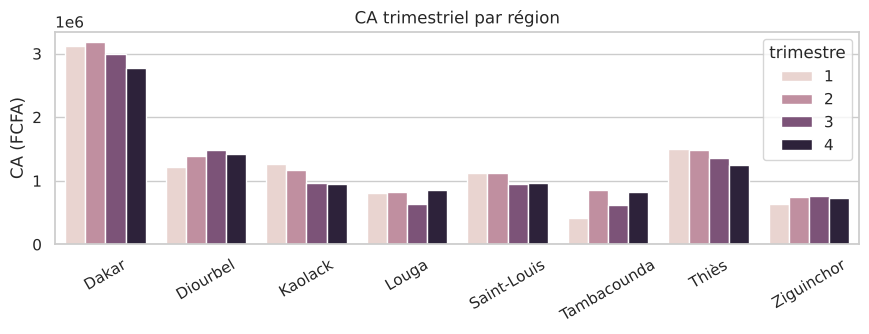

In [4]:
large = ventes.assign(trimestre=ventes["date"].dt.quarter).pivot_table(
    index="region", columns="trimestre", values="montant", aggfunc="sum", observed=True)
long = large.reset_index().melt(id_vars="region", var_name="trimestre", value_name="ca")
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(data=long, x="region", y="ca", hue="trimestre", ax=ax)
ax.set(title="CA trimestriel par région", ylabel="CA (FCFA)", xlabel=""); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Exercice 4 ⭐⭐ — Série temporelle
1. Calculez le CA **hebdomadaire** et sa variation en % d'une semaine à l'autre.
2. Quelle est la semaine record ? Tracez le CA hebdomadaire et une moyenne mobile sur 4 semaines.

semaine record : 2025-12-14 (1,085,460 FCFA)


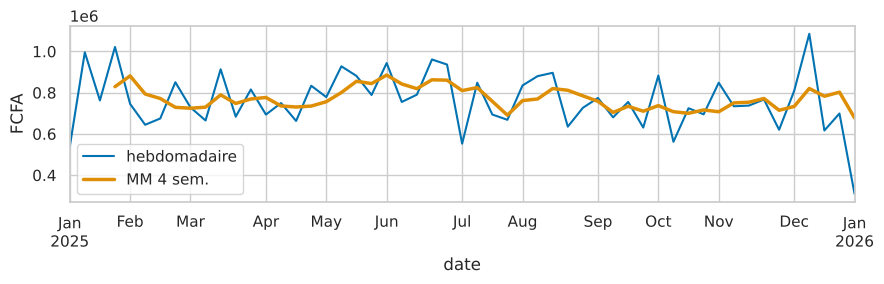

In [5]:
hebdo = ventes.set_index("date")["montant"].resample("W").sum()
var = hebdo.pct_change().mul(100)
print("semaine record :", hebdo.idxmax().date(), f"({hebdo.max():,.0f} FCFA)")
ax = hebdo.plot(figsize=(9, 3), label="hebdomadaire"); hebdo.rolling(4).mean().plot(ax=ax, lw=2.5, label="MM 4 sem.")
ax.legend(); ax.set_ylabel("FCFA"); plt.tight_layout(); plt.show()

## Exercice 5 ⭐⭐ — Visualisation critique
Le graphique ci-dessous est mauvais. Listez au moins 4 problèmes, puis proposez une version corrigée.

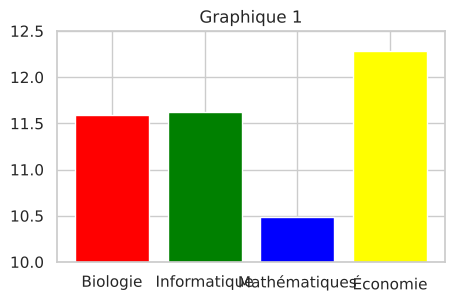

In [6]:
moy = etu.groupby("filiere")["note_examen"].mean()
plt.figure(figsize=(5, 3)); plt.bar(moy.index, moy.values, color=["red", "green", "blue", "yellow"])
plt.ylim(10, 12.5); plt.title("Graphique 1"); plt.show()

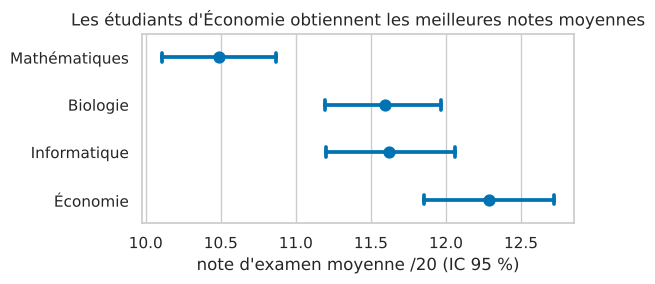

In [7]:
# Problèmes : axe des y tronqué sur un diagramme en barres (exagère les écarts) ; titre non informatif ; pas d'étiquette
# d'axe ni d'unité ; couleurs arbitraires sans signification (et rouge/vert peu accessibles) ; pas d'incertitude ;
# catégories non triées.
fig, ax = plt.subplots(figsize=(6, 3))
ordre = moy.sort_values().index
sns.pointplot(data=etu, y="filiere", x="note_examen", order=ordre, errorbar=("ci", 95), linestyle="none", capsize=.2, ax=ax)
ax.set(title="Les étudiants d'Économie obtiennent les meilleures notes moyennes", xlabel="note d'examen moyenne /20 (IC 95 %)", ylabel="")
plt.tight_layout(); plt.show()

## Exercice 6 ⭐⭐ — Test de comparaison
Les notes d'examen diffèrent-elles entre étudiantes (F) et étudiants (M) ?
Posez H₀/H₁, vérifiez les conditions, faites un test de Welch, donnez la différence avec son IC 95 % et le d de Cohen.
Rédigez la conclusion.

In [8]:
f, mm = etu.loc[etu["sexe"] == "F", "note_examen"], etu.loc[etu["sexe"] == "M", "note_examen"]
r = stats.ttest_ind(f, mm, equal_var=False)
ic = r.confidence_interval()
sp = np.sqrt(((len(f) - 1) * f.var() + (len(mm) - 1) * mm.var()) / (len(f) + len(mm) - 2))
print(f"n = {len(f)} / {len(mm)} ; diff = {f.mean() - mm.mean():.2f} [{ic.low:.2f} ; {ic.high:.2f}] ; p = {r.pvalue:.3f} ; d = {(f.mean() - mm.mean()) / sp:.2f}")
# H0 : mêmes moyennes ; H1 : moyennes différentes. Grands effectifs -> TCL : test t valide.
# Conclusion : pas de différence significative au seuil 5 % ; l'IC contient 0 et la taille d'effet est négligeable.
# (Les données ont été simulées sans effet du sexe : c'est le résultat attendu.)

n = 274 / 326 ; diff = -0.14 [-0.57 ; 0.28] ; p = 0.505 ; d = -0.05


## Exercice 7 ⭐⭐ — χ²
L'admission est-elle indépendante du tutorat ? Donnez le tableau de contingence (en effectifs et en % par ligne),
la statistique χ², la p-valeur, le V de Cramér et une conclusion.

In [9]:
tab = pd.crosstab(etu["tutorat"], etu["admis"])
print(tab); print(pd.crosstab(etu["tutorat"], etu["admis"], normalize="index").mul(100).round(1))
chi2, p, ddl, att = stats.chi2_contingency(tab)
v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
print(f"χ² = {chi2:.2f}, ddl = {ddl}, p = {p:.4f}, V = {v:.2f}")
# Taux d'admission 75 % avec tutorat contre 68 % sans, mais p ≈ 0,07 > 0,05 : on ne rejette pas l'indépendance au
# seuil de 5 % et l'association est faible (V ≈ 0,07). Remarque : au chapitre 7, le tutorat avait un effet significatif
# sur la NOTE ; dichotomiser une variable continue (note -> admis oui/non) fait perdre de la puissance statistique.

admis    Non  Oui
tutorat          
Non      128  269
Oui       50  153
admis     Non   Oui
tutorat            
Non      32.2  67.8
Oui      24.6  75.4
χ² = 3.37, ddl = 1, p = 0.0663, V = 0.07


## Exercice 8 ⭐⭐⭐ — Bootstrap et tests multiples
1. Donnez un IC 95 % bootstrap (5 000 rééchantillonnages) de la **médiane** des heures d'étude.
2. Comparez par test t chaque paire de filières (6 tests). Combien sont significatives à 5 % avant et après correction de Holm ?

In [10]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

b = stats.bootstrap((etu["heures_etude_semaine"].values,), np.median, n_resamples=5000, random_state=0)
print("IC95% médiane :", np.round([b.confidence_interval.low, b.confidence_interval.high], 2))
paires, pv = [], []
for a, c in combinations(sorted(etu["filiere"].unique()), 2):
    paires.append(f"{a} vs {c}")
    pv.append(stats.ttest_ind(etu.loc[etu.filiere == a, "note_examen"], etu.loc[etu.filiere == c, "note_examen"], equal_var=False).pvalue)
rej, p_corr, *_ = multipletests(pv, method="holm")
print(pd.DataFrame({"p brute": np.round(pv, 4), "p Holm": np.round(p_corr, 4), "rejet Holm": rej}, index=paires))

IC95% médiane : [ 9.1 10.2]


                               p brute  p Holm  rejet Holm
Biologie vs Informatique        0.9204  0.9204       False
Biologie vs Mathématiques       0.0001  0.0005        True
Biologie vs Économie            0.0214  0.0641       False
Informatique vs Mathématiques   0.0001  0.0006        True
Informatique vs Économie        0.0337  0.0675       False
Mathématiques vs Économie       0.0000  0.0000        True
